
# Lab: Integrity Breach via Data Poisoning


This lab focuses on **Data Poisoning**, specifically a **Label Flipping** attack. Unlike the previous labs where we attacked a model *after* it was trained, here we are attacking the **training process itself**.

In this exercise, we will convince a Support Vector Machine (SVM) that a specific region of "Class A" territory actually belongs to "Class B."

### Learning Objective

By the end of this lab, you will see how an adversary can create a "backdoor" in a model by injecting a small amount of malicious data into the training set.

---

## 1. Setup and Synthetic Data Generation

We’ll use `scikit-learn` to create a "Moons" dataset. This is perfect for 2D visualization of decision boundaries.

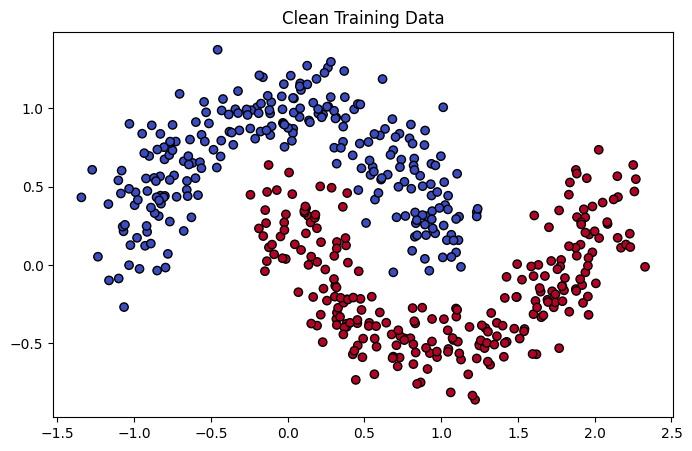

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# 1. Generate clean data
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

def plot_decision_boundary(model, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

# Visualize the clean data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("Clean Training Data")
plt.show()

---

## 2. Establishing the Clean Baseline

First, we train a standard SVM on the clean data to see what a "healthy" model looks like.

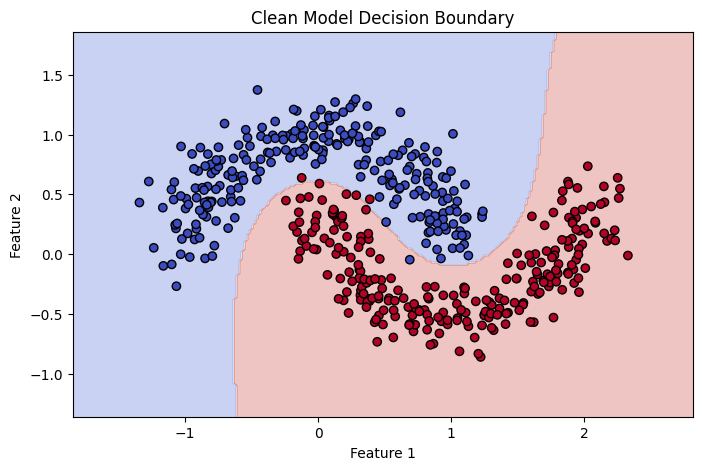

In [ ]:
# Train a standard RBF SVM
clean_model = SVC(kernel='rbf', C=1.0)
clean_model.fit(X, y)

plt.figure(figsize=(8, 5))
plot_decision_boundary(clean_model, X, y, "Clean Model Decision Boundary")
plt.show()

---

## 3. The Poisoning Attack (Label Flipping)

Now, we act as the adversary. We will target a small, specific cluster of points in **Class 1** (the red points) and flip their labels to **Class 0** (blue).



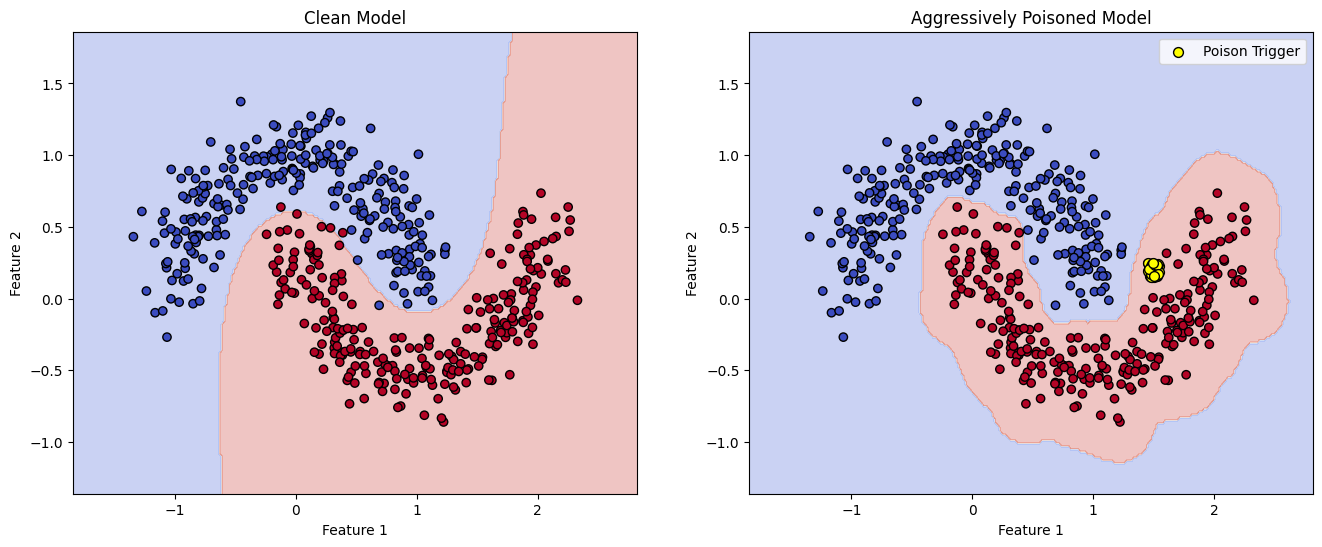

In [ ]:
# 1. Create a dense "Island" of poison
# We will create 20 points centered at (1.5, 0.2)
poison_x = np.random.uniform(1.45, 1.55, 50)
poison_y = np.random.uniform(0.15, 0.25, 50)
X_poison = np.vstack([poison_x, poison_y]).T
# Label them as Class 1 (Blue) even though they are in Class 0 territory
y_poison = np.ones(50) # Label them Blue (1)


# Combine with original data
X_poisoned_combined = np.vstack([X, X_poison])
y_poisoned_combined = np.concatenate([y, y_poison])


# 2. Train the model with higher sensitivity (C and gamma)
# gamma='auto' or a high float makes the boundary much more "wiggly"
poisoned_model = SVC(kernel='rbf', C=1000.0, gamma=50.0)
poisoned_model.fit(X_poisoned_combined, y_poisoned_combined)

# --- VISUALIZATION ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary(clean_model, X, y, "Clean Model")

plt.subplot(1, 2, 2)
# Plot the poisoned model but highlight the poisoned points in yellow
plot_decision_boundary(poisoned_model, X_poisoned_combined, y_poisoned_combined, "Aggressively Poisoned Model")
plt.scatter(X_poison[:, 0], X_poison[:, 1], c='yellow', s=50, edgecolors='k', label='Poison Trigger')
plt.legend()

plt.show()

---

## 4. Testing the Backdoor

To prove the attack worked, let’s test a specific coordinate that *should* be Class 1 but is now captured by the "poisoned" boundary.

In [ ]:
# Test point exactly in the center of the 50-point cluster

test_point = np.array([[0.9, -0.1]])


clean_pred = clean_model.predict(test_point)
poison_pred = poisoned_model.predict(test_point)

print(f"Clean Model Pred: {clean_pred[0]}")
print(f"Poisoned Model Pred: {poison_pred[0]}")

Clean Model Pred: 1
Poisoned Model Pred: 0.0


---

## Lab Discussion Questions

| Feature | Clean Model | Poisoned Model |
| --- | --- | --- |
| **Integrity** | High | Compromised |
| **Accuracy** | High on all regions | High on most, Fail on "Poison Zone" |
| **Boundary Shape** | Smooth, follows natural data | Warped, "reaches" into foreign territory |

1. **The Trigger:** In a real-world scenario (like facial recognition or self-driving cars), what could a "region in 2D space" represent? (e.g., a specific sticker on a stop sign).
2. **Stealth:** If we only poisoned 1% of the data, the overall accuracy of the model would still be 99%. How does this make the attack harder to detect?
3. **Defense:** How could you detect these poisoned points before training? (Hint: Look for points whose labels don't match their neighbors).
